In [1]:
import requests
import pandas as pd
from datetime import datetime

# ThingSpeak channel IDs
CHANNELS = {
    'weather':      3304672,
    'power_rails_a': 3304681,
    'power_rails_b': 3304689,
}

def download_channel(channel_id, channel_name):
    """Download all readings from a ThingSpeak public channel."""
    url = f"https://api.thingspeak.com/channels/{channel_id}/feeds.json"
    
    # Get channel metadata first to know total entry count
    meta = requests.get(url, params={'results': 1}).json()
    total = meta['channel']['last_entry_id']
    print(f"{channel_name}: {total} total entries")
    
    # Download all at once (ThingSpeak allows up to 8000)
    response = requests.get(url, params={'results': 8000}).json()
    
    feeds = response['feeds']
    fields = {k: v for k, v in response['channel'].items() 
              if k.startswith('field')}
    
    print(f"  Downloaded {len(feeds)} readings")
    print(f"  Fields: {fields}")
    return feeds, fields

# Download all three channels
weather_feeds, weather_fields     = download_channel(CHANNELS['weather'],       'Weather')
power_a_feeds, power_a_fields     = download_channel(CHANNELS['power_rails_a'], 'Power Rails A')
power_b_feeds, power_b_fields     = download_channel(CHANNELS['power_rails_b'], 'Power Rails B')

Weather: 902 total entries
  Downloaded 902 readings
  Fields: {'field1': 'Temperature (°C)', 'field2': 'Humidity (%)', 'field3': 'Air Pressure (hPa)', 'field4': 'Rain Count', 'field5': 'Wind Speed (km/h)', 'field6': 'Wind Direction (°)', 'field7': 'Light Level (V)', 'field8': 'Soil Moisture (V)'}
Power Rails A: 845 total entries
  Downloaded 845 readings
  Fields: {'field1': '3.3V Rail (V)', 'field2': '5V Rail (V)', 'field3': 'Battery Voltage (V)', 'field4': 'Solar Voltage (V)', 'field5': 'DC Input Voltage (V)'}
Power Rails B: 808 total entries
  Downloaded 808 readings
  Fields: {'field1': 'Battery Current (A)', 'field2': 'Solar Current (A)'}


In [2]:
# Convert raw ThingSpeak feeds to clean DataFrames
#
# ThingSpeak returns generic field names (field1, field2...).
# We rename them to match our SensorReading model columns exactly so the
# data slots directly into our Django database later.
# The created_at timestamp becomes the DataFrame index — standard for time series.

def feeds_to_df(feeds, rename_map):
    """Convert ThingSpeak feed list to a clean DataFrame."""
    df = pd.DataFrame(feeds)
    df['timestamp'] = pd.to_datetime(df['created_at'], utc=True)
    df = df.set_index('timestamp').drop(columns=['created_at', 'entry_id'])
    df = df.rename(columns=rename_map)
    df = df.apply(pd.to_numeric, errors='coerce')  # 'nan' strings → NaN
    return df

# Weather channel field mapping
weather_map = {
    'field1': 'temperature',
    'field2': 'humidity',
    'field3': 'pressure',
    'field4': 'rain',
    'field5': 'wind_speed',
    'field6': 'wind_direction',
    'field7': 'light',
    'field8': 'soil_moisture',
}

# Power Rails A field mapping
power_a_map = {
    'field1': 'volt_3v3',
    'field2': 'volt_5v',
    'field3': 'volt_batt',
    'field4': 'volt_solar',
    'field5': 'volt_dc',
}

# Power Rails B field mapping
power_b_map = {
    'field1': 'curr_batt',
    'field2': 'curr_solar',
}

df_weather = feeds_to_df(weather_feeds, weather_map)
df_power_a = feeds_to_df(power_a_feeds, power_a_map)
df_power_b = feeds_to_df(power_b_feeds, power_b_map)

print("Weather DataFrame:")
print(df_weather.head(3))
print(f"\nShape: {df_weather.shape}")
print(f"\nMissing values:\n{df_weather.isnull().sum()}")

Weather DataFrame:
                           temperature  humidity  pressure  rain  wind_speed  \
timestamp                                                                      
2026-04-15 16:16:08+00:00        27.60     58.14    874.48     0         0.0   
2026-04-15 16:17:24+00:00        27.61     58.15    874.45     0         0.0   
2026-04-15 16:18:41+00:00        27.58     58.15    874.43     0         0.0   

                           wind_direction  light  soil_moisture  
timestamp                                                        
2026-04-15 16:16:08+00:00             122   2.40           0.05  
2026-04-15 16:17:24+00:00             122   2.32           0.05  
2026-04-15 16:18:41+00:00             122   2.42           0.05  

Shape: (902, 8)

Missing values:
temperature       468
humidity          468
pressure          468
rain                0
wind_speed          0
wind_direction      0
light               0
soil_moisture       0
dtype: int64


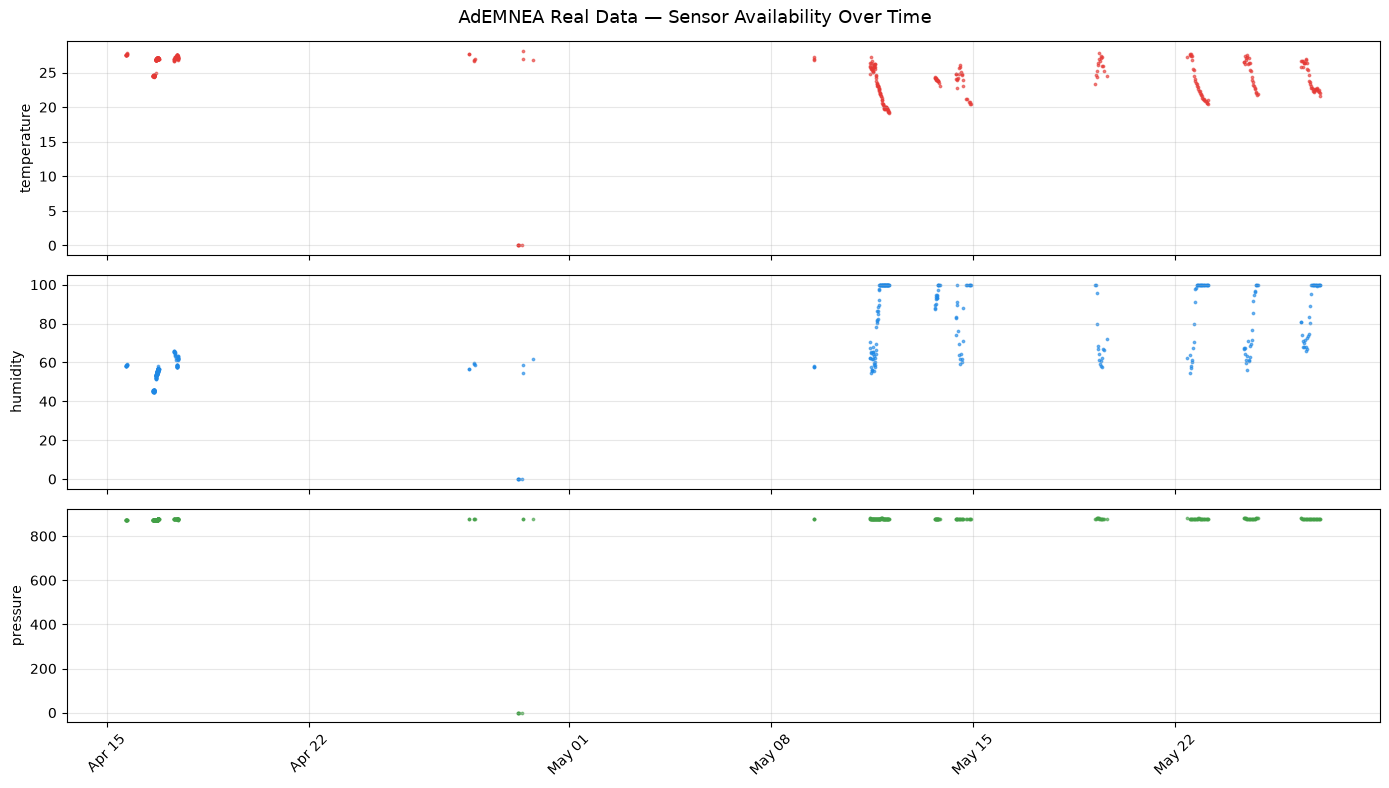

First reading:          2026-04-15 16:16:08+00:00
Last valid temperature: 2026-05-27 00:38:47+00:00
Last reading:           2026-06-24 08:07:11+00:00

Sensor was working for: 41 days 08:22:39
Sensor has been broken: 28 days 07:28:24


In [3]:
# Understand the missing data pattern
#
# 468 out of 902 weather readings have null temperature, humidity and pressure.
# Before we merge and train, we need to understand WHEN the sensor failed —
# was it a sudden break or gradual degradation?
# This tells us whether we can use the nulls as a health label.

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
fig.suptitle('AdEMNEA Real Data — Sensor Availability Over Time', fontsize=13)

for ax, col, color in zip(axes, 
                           ['temperature', 'humidity', 'pressure'],
                           ['#E53935', '#1E88E5', '#43A047']):
    ax.scatter(df_weather.index, 
               df_weather[col], 
               s=3, 
               color=color, 
               alpha=0.6)
    ax.set_ylabel(col)
    ax.grid(True, alpha=0.3)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../data/thingspeak_sensor_availability.png', dpi=150)
plt.show()

# Find exactly when the sensor stopped working
valid = df_weather['temperature'].dropna()
print(f"First reading:          {df_weather.index.min()}")
print(f"Last valid temperature: {valid.index.max()}")
print(f"Last reading:           {df_weather.index.max()}")
print(f"\nSensor was working for: {valid.index.max() - df_weather.index.min()}")
print(f"Sensor has been broken: {df_weather.index.max() - valid.index.max()}")

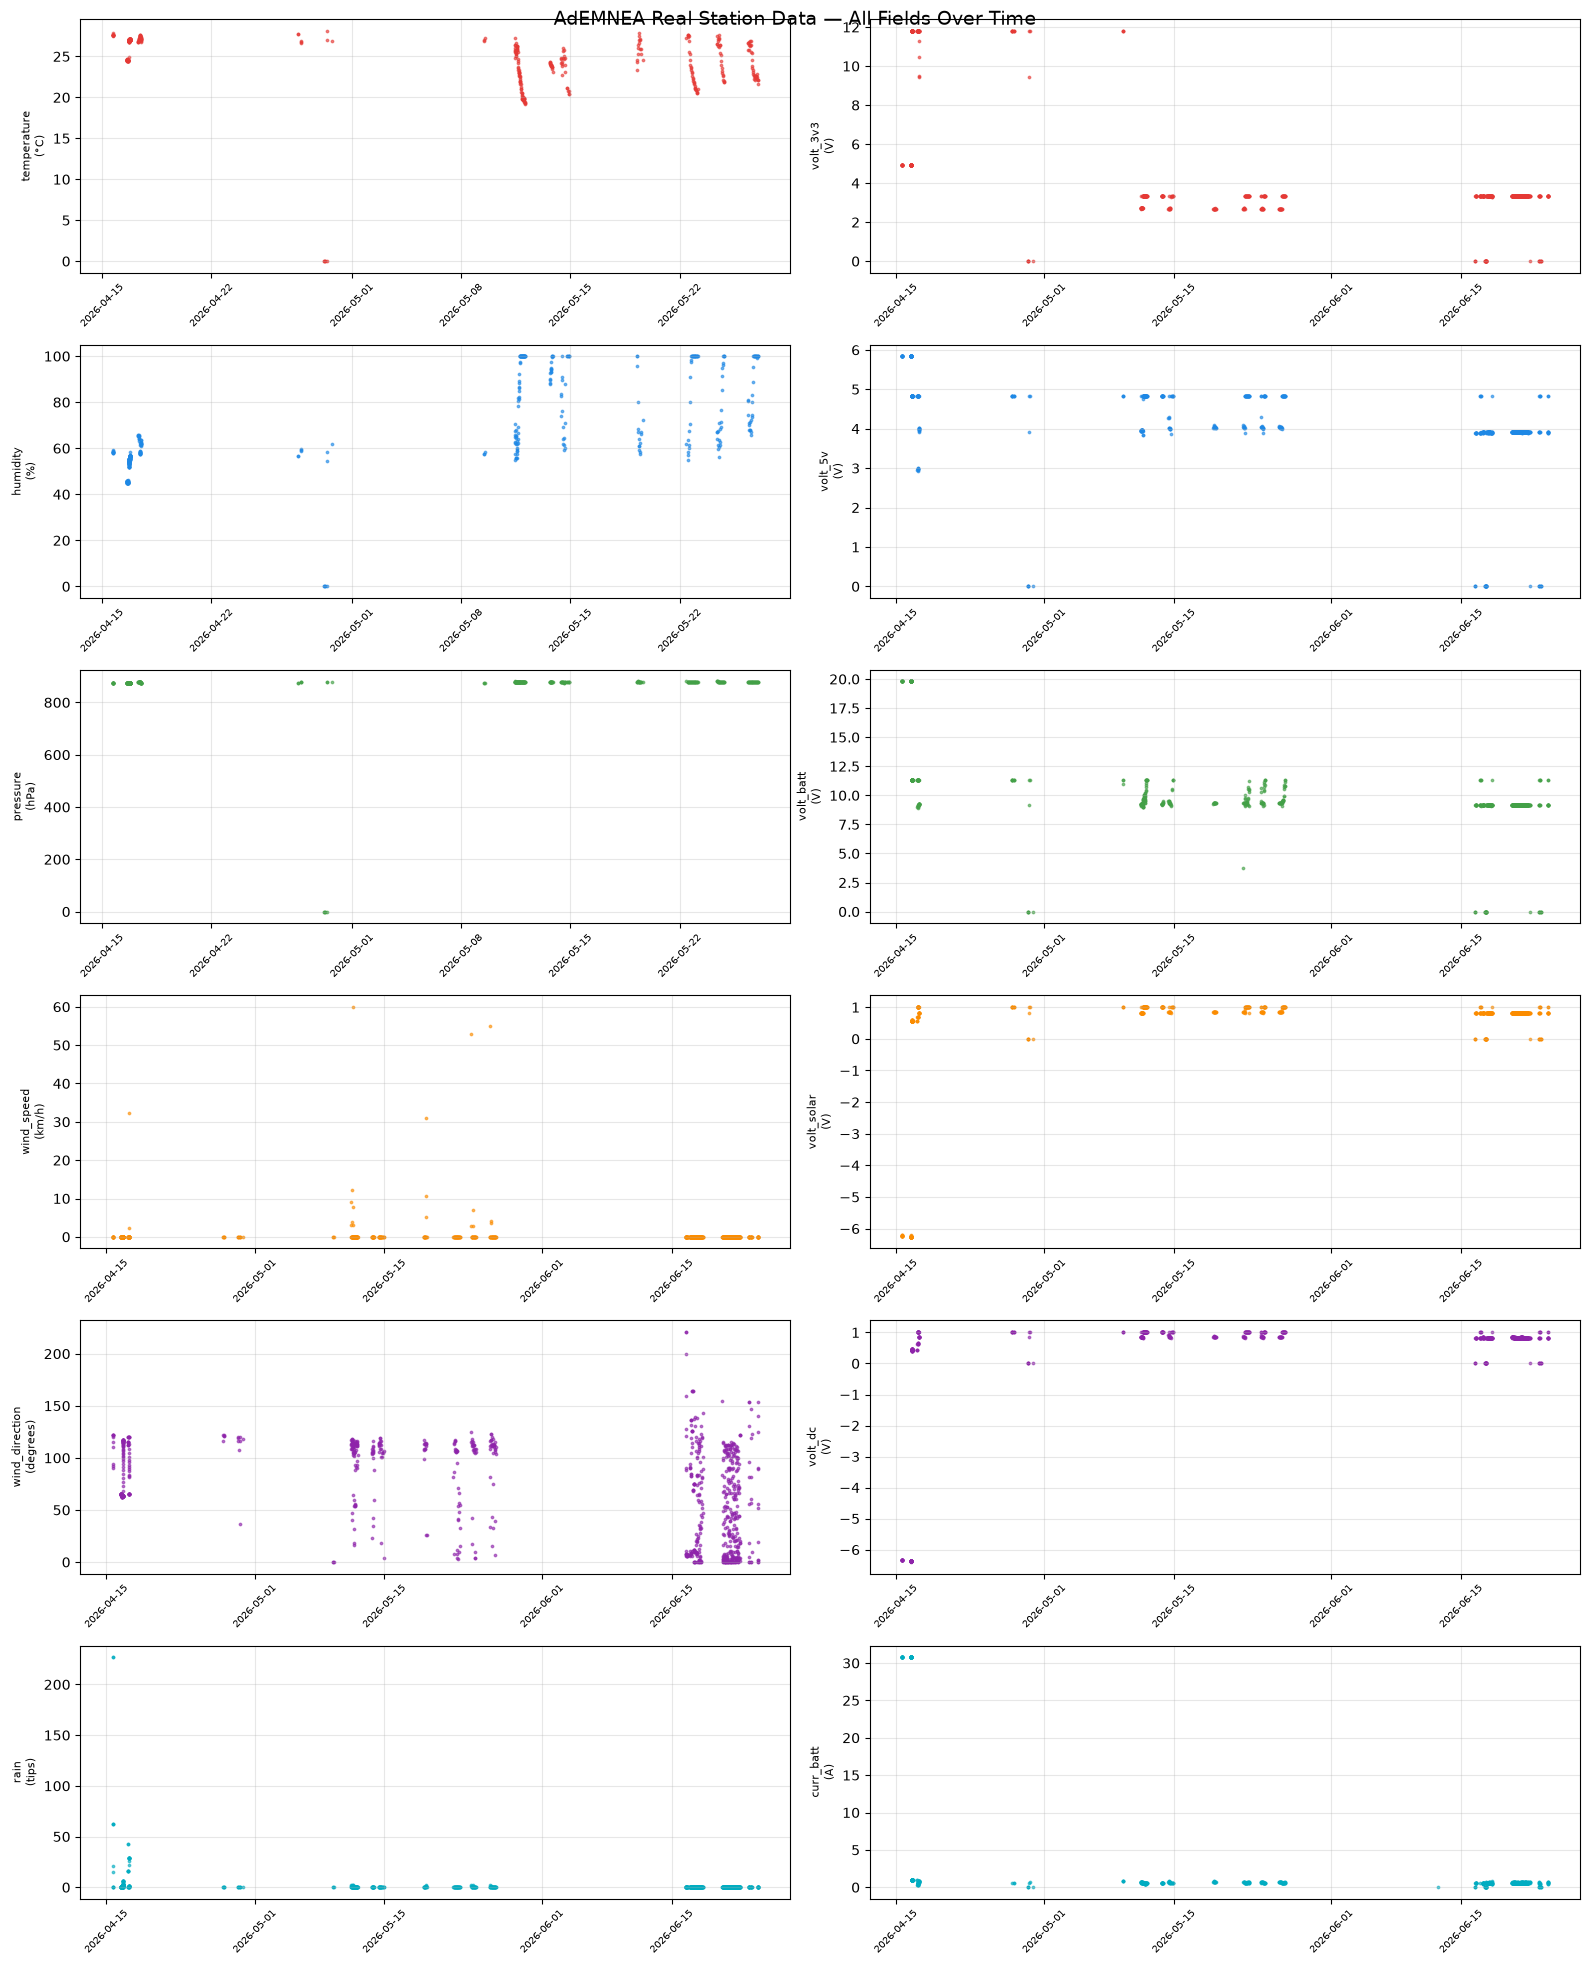

=== WEATHER FIELDS SUMMARY ===
       temperature  humidity  pressure     rain  wind_speed  wind_direction  \
count      434.000   434.000   434.000  902.000     902.000         902.000   
mean        24.811    69.090   866.864    1.553       0.342          70.419   
std          3.540    20.483    93.718   11.930       3.634          44.020   
min          0.000     0.000     0.000    0.000       0.000           0.000   
25%         23.532    55.352   875.055    0.000       0.000          28.500   
50%         25.895    61.585   877.435    0.000       0.000          71.000   
75%         27.010    91.052   878.800    0.000       0.000         110.000   
max         28.110   100.000   880.520  227.000      60.050         221.000   

         light  soil_moisture  
count  902.000        902.000  
mean     0.739          1.830  
std      0.842          1.417  
min      0.000          0.050  
25%      0.000          0.050  
50%      0.330          2.260  
75%      1.518          3.260  
m

In [ ]:
# Full picture — plot ALL sensor fields over time 
#
# This gives a complete view of everything the station was measuring.
# We plot weather fields and power rails together so patterns across
# sensors can be compared — e.g. does battery voltage drop before
# weather sensors fail?

fig, axes = plt.subplots(6, 2, figsize=(16, 20))
fig.suptitle('AdEMNEA Real Station Data — All Fields Over Time', fontsize=14)

# Weather fields
weather_plots = [
    ('temperature',   '#E53935', '°C'),
    ('humidity',      '#1E88E5', '%'),
    ('pressure',      '#43A047', 'hPa'),
    ('wind_speed',    '#FB8C00', 'km/h'),
    ('wind_direction','#8E24AA', 'degrees'),
    ('rain',          '#00ACC1', 'tips'),
    ('light',         '#FFD600', 'V'),
    ('soil_moisture', '#6D4C41', 'V'),
]

# Power rail fields
power_plots = [
    ('volt_3v3',   '#E53935', 'V'),
    ('volt_5v',    '#1E88E5', 'V'),
    ('volt_batt',  '#43A047', 'V'),
    ('volt_solar', '#FB8C00', 'V'),
    ('volt_dc',    '#8E24AA', 'V'),
    ('curr_batt',  '#00ACC1', 'A'),
    ('curr_solar', '#FFD600', 'A'),
]

# Merge power rails A and B
df_power = df_power_a.join(df_power_b, how='outer')

# Plot weather fields (left column)
for i, (col, color, unit) in enumerate(weather_plots[:6]):
    ax = axes[i][0]
    ax.scatter(df_weather.index, df_weather[col], s=3, color=color, alpha=0.6)
    ax.set_ylabel(f'{col}\n({unit})', fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45, labelsize=7)

# Plot power fields (right column)
for i, (col, color, unit) in enumerate(power_plots[:6]):
    ax = axes[i][1]
    ax.scatter(df_power.index, df_power[col], s=3, color=color, alpha=0.6)
    ax.set_ylabel(f'{col}\n({unit})', fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45, labelsize=7)

plt.tight_layout()
plt.savefig('../data/thingspeak_all_fields.png', dpi=150)
plt.show()

# Print summary statistics
print("=== WEATHER FIELDS SUMMARY ===")
print(df_weather.describe().round(3))
print("\n=== POWER RAILS SUMMARY ===")
print(df_power.describe().round(3))

In [5]:
# Clean outliers and merge all three channels 
#
# The power rail data has physically impossible values:
# - Negative voltages and currents (sensor noise)
# - Zero voltages on rails that should always be positive when station is on
# - Extreme current spikes (30A on a solar-powered IoT device is impossible)
#
# We clip values to physically realistic ranges for this hardware:
# - volt_3v3: 2.5V to 4.0V (3.3V rail with tolerance)
# - volt_5v: 3.5V to 6.0V (5V rail with tolerance)  
# - volt_batt: 8.0V to 15.0V (12V lead acid battery range)
# - volt_solar: 0V to 25V (solar panel open circuit)
# - curr_batt/curr_solar: 0A to 5A (realistic for this size system)
#
# After cleaning we merge all three channels on timestamp using
# nearest-match joining since the three channels post at slightly
# different times.

# Clean power rails A
df_power_a_clean = df_power_a.copy()
df_power_a_clean['volt_3v3']   = df_power_a['volt_3v3'].clip(2.5, 4.0)
df_power_a_clean['volt_5v']    = df_power_a['volt_5v'].clip(3.5, 6.0)
df_power_a_clean['volt_batt']  = df_power_a['volt_batt'].clip(8.0, 15.0)
df_power_a_clean['volt_solar'] = df_power_a['volt_solar'].clip(0.0, 25.0)
df_power_a_clean['volt_dc']    = df_power_a['volt_dc'].clip(0.0, 6.0)

# Clean power rails B
df_power_b_clean = df_power_b.copy()
df_power_b_clean['curr_batt']  = df_power_b['curr_batt'].clip(0.0, 5.0)
df_power_b_clean['curr_solar'] = df_power_b['curr_solar'].clip(0.0, 5.0)

# Merge all three channels
# sort_index ensures chronological order before merging
df_weather_s = df_weather.sort_index()
df_power_a_s = df_power_a_clean.sort_index()
df_power_b_s = df_power_b_clean.sort_index()

# merge_asof joins on nearest timestamp within 5 minutes
df_merged = pd.merge_asof(
    df_weather_s,
    df_power_a_s,
    left_index=True,
    right_index=True,
    tolerance=pd.Timedelta('5min'),
    direction='nearest'
)
df_merged = pd.merge_asof(
    df_merged,
    df_power_b_s,
    left_index=True,
    right_index=True,
    tolerance=pd.Timedelta('5min'),
    direction='nearest'
)

print(f"Merged dataset shape: {df_merged.shape}")
print(f"Date range: {df_merged.index.min()} → {df_merged.index.max()}")
print(f"\nColumns: {list(df_merged.columns)}")
print(f"\nMissing values after merge:")
print(df_merged.isnull().sum())
print(f"\nPower rails after cleaning:")
print(df_merged[['volt_batt', 'volt_solar', 'curr_batt', 'curr_solar']].describe().round(3))

Merged dataset shape: (902, 15)
Date range: 2026-04-15 16:16:08+00:00 → 2026-06-24 08:07:11+00:00

Columns: ['temperature', 'humidity', 'pressure', 'rain', 'wind_speed', 'wind_direction', 'light', 'soil_moisture', 'volt_3v3', 'volt_5v', 'volt_batt', 'volt_solar', 'volt_dc', 'curr_batt', 'curr_solar']

Missing values after merge:
temperature       468
humidity          468
pressure          468
rain                0
wind_speed          0
wind_direction      0
light               0
soil_moisture       0
volt_3v3           49
volt_5v            49
volt_batt          49
volt_solar         49
volt_dc            49
curr_batt          75
curr_solar         75
dtype: int64

Power rails after cleaning:
       volt_batt  volt_solar  curr_batt  curr_solar
count    853.000     853.000    827.000     827.000
mean       9.967       0.749      0.900       0.778
std        1.526       0.270      1.038       1.078
min        8.000       0.000      0.000       0.000
25%        9.170       0.820      0.5

In [6]:
# Create station health labels from real patterns 
#
# Unlike the NOAA proxy data where we labelled gaps as downtime,
# here we have TWO real failure signals in the actual AdEMNEA data:
#
# Signal 1 — Atmospheric sensor failure (May 27)
#   Temperature/humidity/pressure went permanently null on May 27.
#   Readings in the 6 hours BEFORE that failure are labelled at_risk.
#   This represents a PARTIAL failure — station still transmitting
#   but one sensor module is dead.
#
# Signal 2 — Transmission gaps
#   Any gap longer than 30 minutes (station posts ~every 13 minutes)
#   means the station stopped transmitting entirely.
#   Readings in the 2 readings BEFORE each gap are labelled at_risk.
#
# Everything else is labelled healthy.

df_labelled = df_merged.copy()
df_labelled['status'] = 'healthy'

# ── Signal 1: Atmospheric sensor failure ──────────────────────────────────
sensor_failure_time = df_merged['temperature'].dropna().index.max()
print(f"Atmospheric sensor failed at: {sensor_failure_time}")

# Mark 6 hours before the failure as at_risk
at_risk_window = df_labelled[
    (df_labelled.index >= sensor_failure_time - pd.Timedelta(hours=6)) &
    (df_labelled.index <= sensor_failure_time)
].index
df_labelled.loc[at_risk_window, 'status'] = 'at_risk'
print(f"Readings labelled at_risk (sensor failure): {len(at_risk_window)}")

# ── Signal 2: Transmission gaps ───────────────────────────────────────────
time_diffs = df_labelled.index.to_series().diff()
gaps = time_diffs[time_diffs > pd.Timedelta(minutes=30)]
print(f"\nTransmission gaps found: {len(gaps)}")
print(f"Longest gap: {gaps.max()}")

gap_count = 0
for gap_time in gaps.index:
    # Find the 2 readings immediately before this gap
    before_gap = df_labelled[df_labelled.index < gap_time].tail(2).index
    df_labelled.loc[before_gap, 'status'] = 'at_risk'
    gap_count += len(before_gap)

print(f"Readings labelled at_risk (transmission gaps): {gap_count}")

# ── Final label distribution ──────────────────────────────────────────────
print(f"\nFinal label distribution:")
print(df_labelled['status'].value_counts())
print(f"\nAt_risk percentage: {(df_labelled['status']=='at_risk').mean()*100:.1f}%")

Atmospheric sensor failed at: 2026-05-27 00:38:47+00:00
Readings labelled at_risk (sensor failure): 13

Transmission gaps found: 62
Longest gap: 20 days 12:07:48
Readings labelled at_risk (transmission gaps): 124

Final label distribution:
status
healthy    773
at_risk    129
Name: count, dtype: int64

At_risk percentage: 14.3%


In [7]:
# Feature engineering on real AdEMNEA data 
#
# Same approach as the NOAA notebook but now we have the power rail
# features that were missing before. These are the strongest predictors
# of station health — battery voltage dropping is the clearest early
# warning sign of an impending failure.
#
# Rolling features capture TRENDS over the last 3 readings:
# - mean_3: average over last 3 readings (smooths noise)
# - trend_3: difference between newest and oldest in window (direction)
#
# hour_of_day captures the solar charging cycle —
# stations are most vulnerable at night when batteries are draining.

df_feat = df_labelled.copy()

# Rolling features for weather sensors
for col in ['temperature', 'wind_speed', 'soil_moisture']:
    df_feat[f'{col}_mean_3'] = df_feat[col].rolling(3, min_periods=1).mean()
    df_feat[f'{col}_trend_3'] = df_feat[col].diff(3)

# Rolling features for power rails — most important features
for col in ['volt_batt', 'volt_solar', 'curr_batt', 'curr_solar']:
    df_feat[f'{col}_mean_3'] = df_feat[col].rolling(3, min_periods=1).mean()
    df_feat[f'{col}_trend_3'] = df_feat[col].diff(3)

# Time features
df_feat['hour_of_day'] = df_feat.index.hour
df_feat['hours_since_last'] = df_feat.index.to_series().diff().dt.total_seconds() / 3600

print("Features created:")
print([c for c in df_feat.columns if c != 'status'])
print(f"\nTotal features: {len(df_feat.columns) - 1}")

Features created:
['temperature', 'humidity', 'pressure', 'rain', 'wind_speed', 'wind_direction', 'light', 'soil_moisture', 'volt_3v3', 'volt_5v', 'volt_batt', 'volt_solar', 'volt_dc', 'curr_batt', 'curr_solar', 'temperature_mean_3', 'temperature_trend_3', 'wind_speed_mean_3', 'wind_speed_trend_3', 'soil_moisture_mean_3', 'soil_moisture_trend_3', 'volt_batt_mean_3', 'volt_batt_trend_3', 'volt_solar_mean_3', 'volt_solar_trend_3', 'curr_batt_mean_3', 'curr_batt_trend_3', 'curr_solar_mean_3', 'curr_solar_trend_3', 'hour_of_day', 'hours_since_last']

Total features: 31


In [8]:
# Train Random Forest on real AdEMNEA data 
#
# Same pipeline as the NOAA notebook but with real data and power features.
# We expect significantly better recall on at_risk cases because:
# 1. Labels come from real hardware failures, not proxy weather gaps
# 2. Power rail features (volt_batt, curr_solar) directly measure
#    the hardware conditions that precede station failure
# 3. 14.3% at_risk ratio is more balanced than the 3.6% we had before

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Define feature columns — exclude status and non-feature columns
feature_cols = [c for c in df_feat.columns if c != 'status']

# Drop rows with NaN in any feature
df_clean = df_feat[feature_cols + ['status']].dropna()
print(f"Shape before dropna: {df_feat.shape}")
print(f"Shape after dropna:  {df_clean.shape}")
print(f"Rows dropped: {len(df_feat) - len(df_clean)}")

X = df_clean[feature_cols]
y = df_clean['status']

print(f"\nLabel distribution after cleaning:")
print(y.value_counts())

# Split — stratified to preserve at_risk ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\nTraining set: {X_train.shape[0]} rows")
print(f"Test set:     {X_test.shape[0]} rows")

# Train
model_v2 = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

print("\nTraining model on real AdEMNEA data...")
model_v2.fit(X_train, y_train)
print("Done.")

# Evaluate
y_pred = model_v2.predict(X_test)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Feature importance
importances = pd.Series(
    model_v2.feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

print("\nTop 10 most important features:")
print(importances.head(10).round(4))

Shape before dropna: (902, 32)
Shape after dropna:  (406, 32)
Rows dropped: 496

Label distribution after cleaning:
status
healthy    354
at_risk     52
Name: count, dtype: int64

Training set: 324 rows
Test set:     82 rows

Training model on real AdEMNEA data...
Done.

Classification Report:
              precision    recall  f1-score   support

     at_risk       0.54      0.64      0.58        11
     healthy       0.94      0.92      0.93        71

    accuracy                           0.88        82
   macro avg       0.74      0.78      0.76        82
weighted avg       0.89      0.88      0.88        82


Top 10 most important features:
temperature_mean_3    0.0855
volt_batt_trend_3     0.0762
humidity              0.0684
temperature           0.0614
curr_batt_mean_3      0.0495
hours_since_last      0.0433
light                 0.0419
wind_direction        0.0415
pressure              0.0401
volt_batt             0.0383
dtype: float64


In [9]:
# Save the improved model 
#
# This replaces the NOAA proxy model with one trained on real AdEMNEA data.
# The model files go into ml/models/ — the same location FastAPI loads from.
# After committing and pushing, Render will automatically redeploy FastAPI
# with the improved model. No infrastructure changes needed.
#
# We also save the new feature list — it's different from the NOAA model
# (31 features vs 11) so FastAPI and Django's call_ml_service() must both
# use this updated list.

import joblib
import os

# Find the best threshold for this model
from sklearn.metrics import precision_recall_curve
import numpy as np

y_proba = model_v2.predict_proba(X_test)
at_risk_col = list(model_v2.classes_).index('at_risk')
at_risk_proba = y_proba[:, at_risk_col]

precisions, recalls, thresholds = precision_recall_curve(
    y_test, at_risk_proba, pos_label='at_risk'
)

# Find threshold where recall >= 0.6
good = thresholds[recalls[:-1] >= 0.6]
best_threshold = float(good[-1]) if len(good) > 0 else 0.5
print(f"Best threshold for recall >= 0.6: {best_threshold:.3f}")

# Save
os.makedirs('../models', exist_ok=True)
joblib.dump(model_v2,       '../models/station_health_model.pkl')
joblib.dump(best_threshold, '../models/classification_threshold.pkl')
joblib.dump(feature_cols,   '../models/feature_cols.pkl')

print("\nSaved:")
print("  ../models/station_health_model.pkl")
print("  ../models/classification_threshold.pkl")
print("  ../models/feature_cols.pkl")

# Verify
loaded_features = joblib.load('../models/feature_cols.pkl')
print(f"\nFeature count: {len(loaded_features)}")
print(f"Threshold: {best_threshold:.3f}")

Best threshold for recall >= 0.6: 0.538

Saved:
  ../models/station_health_model.pkl
  ../models/classification_threshold.pkl
  ../models/feature_cols.pkl

Feature count: 31
Threshold: 0.538
